# Analysing Stock Prices

In this notebook, we will be analysing stock prices using Python. We will be using the pandas library to read and manipulate the data, and the matplotlib library to visualize the data. To start of, we will import the `yfinance` libraries and read in the stock price data between `2007-1-1` to `2026-01-01`, and save them in the `prices` folder in the working directory.

For those viewing the project on GitHub, I have provided a download script within this notebook file which will fetch the stock price data from Yahoo Finance and save it in a `price` folder in your working directory .

In [1]:
%%writefile capture_stock_prices.py
import argparse
import csv
import logging
import os
import re
import sys
import time

import yfinance as yf

logging.getLogger("yfinance").setLevel(logging.CRITICAL)

START_DATE = "2007-01-01"
END_DATE = "2026-01-01"
PRICES_DIR = "prices"
SYMBOLS_FILE = "nasdaqlisted.txt"
REQUEST_DELAY = 0.05
MAX_RETRIES = 3
PROGRESS_EVERY = 100
FAILED_LOG = "failed_symbols.csv"

COLUMNS = ["date", "open", "high", "low", "close", "adj_close", "volume"]

NON_EQUITY = re.compile(
    r"\bETN\b|\bETF\b|Exchange[- ]Traded|"
    r"\bWarrant|\bRight\b|\bRights\b|\bUnit\b|\bUnits\b|"
    r"Depositary Share|Depositary Receipt|Preferred|"
    r"Closed End Fund|Trust Preferred|Notes? due|\bDebenture",
    re.I,
)


def load_symbols(path, common_stock_only=True):
    if not os.path.exists(path):
        sys.exit(
            f"No symbol list found at '{path}'.\n"
            "Use a plain list, NASDAQ's nasdaqlisted.txt, or --symbols AAPL MSFT ..."
        )

    with open(path, encoding="utf-8") as f:
        first = f.readline()
        f.seek(0)

        # NASDAQ listing files are pipe-delimited with a Symbol column
        if "|" in first and "Symbol" in first:
            reader = csv.DictReader(f, delimiter="|")
            symbols = []
            dropped = {"test": 0, "etf": 0, "non_equity": 0, "suffixed": 0}

            for row in reader:
                symbol = (row.get("Symbol") or "").strip().upper()
                name = row.get("Security Name") or ""

                # Trailing footer line: "File Creation Time: ...|||||||"
                if not symbol or symbol.startswith("FILE CREATION"):
                    continue
                # Test tickers exist purely for exchange system checks
                if row.get("Test Issue", "").strip().upper() == "Y":
                    dropped["test"] += 1
                    continue
                if common_stock_only and row.get("ETF", "").strip().upper() == "Y":
                    dropped["etf"] += 1
                    continue
                if common_stock_only and NON_EQUITY.search(name):
                    dropped["non_equity"] += 1
                    continue
                # Suffixed symbols use different conventions on Yahoo and mostly 404
                if not symbol.isalpha():
                    dropped["suffixed"] += 1
                    continue

                symbols.append(symbol)

            print(
                f"Parsed NASDAQ listing: {len(symbols):,} symbols "
                f"({dropped['test']} test issues, {dropped['etf']} ETFs, "
                f"{dropped['non_equity']} non-equity instruments, "
                f"{dropped['suffixed']} suffixed tickers excluded)"
            )
            return symbols

        # Plain one-per-line list
        return [
            line.strip().upper()
            for line in f
            if line.strip() and not line.startswith("#")
        ]


def fetch_symbol(symbol, start, end, retry_empty=False):
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            df = yf.Ticker(symbol).history(
                start=start,
                end=end,
                interval="1d",
                auto_adjust=False,
            )
            if not df.empty:
                return df, None
            if not retry_empty or attempt == MAX_RETRIES:
                return None, "no data returned"
        except Exception as exc:
            if attempt == MAX_RETRIES:
                return None, f"{type(exc).__name__}: {exc}"
        # Back off progressively rather than hammering a rate limit
        time.sleep(2 ** attempt)
    return None, "no data returned"


def write_csv(symbol, df, out_dir):
    """Write the DataFrame to <out_dir>/<symbol>.csv in the target schema."""
    path = os.path.join(out_dir, f"{symbol}.csv")
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(COLUMNS)
        for date, row in df.iterrows():
            writer.writerow([
                date.strftime("%Y-%m-%d"),
                round(row["Open"], 4),
                round(row["High"], 4),
                round(row["Low"], 4),
                round(row["Close"], 4),
                round(row.get("Adj Close", row["Close"]), 4),
                int(row["Volume"]),
            ])
    return path


def main():
    parser = argparse.ArgumentParser(description="Download NASDAQ daily prices.")
    parser.add_argument("--symbols", nargs="+", help="Tickers to fetch (overrides the symbol file)")
    parser.add_argument("--start", default=START_DATE, help="Start date, YYYY-MM-DD")
    parser.add_argument("--end", default=END_DATE, help="End date, YYYY-MM-DD")
    parser.add_argument("--out", default=PRICES_DIR, help="Output directory")
    parser.add_argument("--force", action="store_true", help="Re-download existing files")
    parser.add_argument("--symbol-file", default=SYMBOLS_FILE, help="Plain list or nasdaqlisted.txt")
    parser.add_argument("--all-instruments", action="store_true",
                        help="Keep ETFs, ETNs, warrants and other non-equity listings")
    parser.add_argument("--limit", type=int, help="Only fetch the first N symbols")
    parser.add_argument("--verbose", action="store_true", help="Print a line per symbol")
    parser.add_argument("--retry-empty", action="store_true",
                        help="Retry empty results (distinguishes throttling from delisting)")
    parser.add_argument("--delay", type=float, default=REQUEST_DELAY, help="Seconds between requests")
    args = parser.parse_args()

    symbols = args.symbols or load_symbols(args.symbol_file, not args.all_instruments)
    symbols = [s.upper() for s in symbols]
    if args.limit:
        symbols = symbols[:args.limit]
    os.makedirs(args.out, exist_ok=True)

    print(f"{len(symbols):,} symbols | {args.start} to {args.end} | -> {args.out}/")

    # Resume: anything already written is skipped unless --force
    pending = [
        s for s in symbols
        if args.force or not os.path.exists(os.path.join(args.out, f"{s}.csv"))
    ]
    skipped = len(symbols) - len(pending)
    if skipped:
        print(f"{skipped:,} already downloaded, {len(pending):,} to fetch")
    if not pending:
        print("Nothing to do.")
        return
    print()

    downloaded, failures = 0, []
    started = time.monotonic()

    for i, symbol in enumerate(pending, 1):
        df, reason = fetch_symbol(symbol, args.start, args.end, args.retry_empty)

        if df is None:
            failures.append((symbol, reason))
            if args.verbose:
                print(f"  {symbol}: {reason}")
        else:
            write_csv(symbol, df, args.out)
            downloaded += 1
            if args.verbose:
                print(f"  {symbol}: {len(df)} rows")

        # One line per PROGRESS_EVERY symbols keeps the notebook readable
        if not args.verbose and (i % PROGRESS_EVERY == 0 or i == len(pending)):
            rate = i / max(time.monotonic() - started, 1e-9)
            print(
                f"{i:,}/{len(pending):,} processed | "
                f"{downloaded:,} ok | {len(failures):,} failed | "
                f"{rate:.1f}/s",
                flush=True,
            )

        time.sleep(args.delay)

    elapsed = time.monotonic() - started
    print(f"\nDone in {elapsed / 60:.1f} min: {downloaded:,} downloaded, "
          f"{skipped:,} already present, {len(failures):,} failed.")

    if failures:
        with open(FAILED_LOG, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["symbol", "reason"])
            writer.writerows(failures)

        share = len(failures) / len(pending)
        print(f"Failure detail written to {FAILED_LOG} ({share:.0%} of attempted).")
        print("Symbols listed in nasdaqlisted.txt as of April 2017 may since have "
              "been delisted, acquired or renamed. Yahoo also returns an empty "
              "result when rate limiting, so a high failure rate at a low --delay "
              "may not all be genuine: re-run a sample with --retry-empty "
              "--delay 1.0 to check.")


if __name__ == "__main__":
    main()

Overwriting capture_stock_prices.py


In [2]:
%run capture_stock_prices.py

Parsed NASDAQ listing: 2,472 symbols (9 test issues, 301 ETFs, 389 non-equity instruments, 0 suffixed tickers excluded)
2,472 symbols | 2007-01-01 to 2026-01-01 | -> prices/
1,363 already downloaded, 1,109 to fetch

100/1,109 processed | 0 ok | 100 failed | 4.6/s
200/1,109 processed | 0 ok | 200 failed | 4.8/s
300/1,109 processed | 0 ok | 300 failed | 4.7/s
400/1,109 processed | 0 ok | 400 failed | 4.6/s
500/1,109 processed | 0 ok | 500 failed | 4.6/s
600/1,109 processed | 0 ok | 600 failed | 4.6/s
700/1,109 processed | 0 ok | 700 failed | 4.6/s
800/1,109 processed | 0 ok | 800 failed | 4.6/s
900/1,109 processed | 0 ok | 900 failed | 4.7/s
1,000/1,109 processed | 0 ok | 1,000 failed | 4.7/s
1,100/1,109 processed | 0 ok | 1,100 failed | 4.7/s
1,109/1,109 processed | 0 ok | 1,109 failed | 4.7/s

Done in 3.9 min: 0 downloaded, 1,363 already present, 1,109 failed.
Failure detail written to failed_symbols.csv (100% of attempted).
Symbols listed in nasdaqlisted.txt as of April 2017 may since

The download completed for 1,363 of 2,472 symbols. That is ample for this exercise, but a 49% failure rate is worth pausing on rather than waving through.

Two explanations are plausible, and they have different implications:

1. **Genuine attrition**: `nasdaqlisted.txt` is a snapshot from April 2017.
   Nearly a decade of delistings, acquisitions and ticker changes sits between that file and today - ANSS (Ansys) and MXIM (Maxim Integrated) both appear in the failure list, and both were acquired.
2. **Rate limiting**: Yahoo returns an empty result both for a ticker that no longer exists *and* for a request it declined to serve. The download ran with a 0.05s delay between requests; if that tripped throttling, some unknown share of these failures are false rather than dead tickers.

The two are indistinguishable from the response alone, which is the awkward part: if the second explanation carries real weight, the surviving sample is biased by whichever requests happened to get through, not by which companies still exist. Failure reasons are written to `failed_symbols.csv` and re-running a sample with `--retry-empty --delay 1.0` would separate the cases. **Based on my re-run results, it appears the failures can be attributed to genuine attrition**.

In a commercial setting this would need resolving before the data was used for anything, alongside the wider questions of storage, refresh cadence and validation that a one-off download sidesteps.

### Comparing ingestion methods

With the files on disk, the next question is how to read them efficiently - and more usefully, *why* one approach should beat another. The sections below benchmark six loaders across two dimensions:

- **Parser**: pandas' `read_csv` against PyArrow's CSV reader
- **Concurrency**: serial, a thread pool, and a process pool

Varying both gives a 2×3 grid, so each effect can be isolated: reading across a row will show the concurrency effect at a fixed parser, and down a column the parser effect at fixed concurrency. Comparing only two methods would confound the two.

Every loader returns the same structure, a dictionary mapping ticker to a DataFrame indexed by date, with the same seven columns, so the comparison reflects the method rather than differing amounts of work. Each is timed as the median of three warm runs, discarding a first pass that reads from cold disk cache; without that, whichever method runs first is unfairly penalised. The machine has 12 physical cores and 24 logical threads, which sets the ceiling on what parallelism can achieve.

Results are collected as each method runs and compared in the conclusion.

In [3]:
# Method 1 — pandas, single process (baseline)
import os
import time
from statistics import median

import pandas as pd
from IPython.display import clear_output

DIRECTORY = "prices"
COLUMNS = ["date", "open", "high", "low", "close", "adj_close", "volume"]
RUNS = 5
PROGRESS_EVERY = 100

results = {}
_progress_mark = 0

def price_files(directory=DIRECTORY):
    return sorted(f for f in os.listdir(directory) if f.lower().endswith(".csv"))

def progress(i, total, label, every=PROGRESS_EVERY):
    global _progress_mark
    if i == total or i - _progress_mark >= every:
        _progress_mark = 0 if i == total else i
        clear_output(wait=True)
        bar = "#" * int(20 * i / total)
        print(f"{label}\n  [{bar:<20}] {i:,}/{total:,} files ({i / total:.0%})")

def benchmark(name, loader, runs=RUNS):
    timings = []
    for run in range(runs + 1):
        tag = "cold run" if run == 0 else f"run {run}/{runs}"
        start = time.perf_counter()
        data = loader(f"{name} — {tag}")
        timings.append(time.perf_counter() - start)

    warm = timings[1:]
    results[name] = median(warm)

    clear_output(wait=True)
    print(f"{name}")
    print(f"{len(data):,} tickers | {results[name]:.2f}s median of {runs} warm runs (cold run: {timings[0]:.2f}s)")
    return data

def load_pandas_serial(label="pandas, serial"):
    files = price_files()
    out = {}
    for i, f in enumerate(files, 1):
        out[os.path.splitext(f)[0]] = pd.read_csv(
            os.path.join(DIRECTORY, f),
            usecols=COLUMNS,
            parse_dates=["date"],
            index_col="date",
        )
        progress(i, len(files), label)
    return out

stock_prices = benchmark("pandas, serial", load_pandas_serial)

pandas, serial
1,363 tickers | 7.99s median of 5 warm runs (cold run: 7.92s)


In [4]:
%%writefile file_ingest.py
# Initial read of all stock prices
import os
import pandas as pd

def mapper(file_chunk, directory, columns):
    prices = {}
    for file in file_chunk:
        name = os.path.splitext(file)[0]
        prices[name] = pd.read_csv(
            os.path.join(directory, file),
            usecols=columns,
            parse_dates=["date"],
            index_col="date",
            encoding="utf-8",
        )
    return prices, len(file_chunk)

def reducer(accumulated, chunk):
    accumulated.update(chunk)
    return accumulated

Overwriting file_ingest.py


In [5]:
# Method 2 — pandas, multiple processes
import functools
import importlib
import math
from multiprocessing import Pool

import file_ingest
importlib.reload(file_ingest)
from file_ingest import mapper, reducer

WORKERS = os.cpu_count()

def make_chunks(items, num_chunks):
    size = math.ceil(len(items) / num_chunks)
    return [items[i:i + size] for i in range(0, len(items), size)]

def load_pandas_parallel(label="pandas, parallel"):
    files = price_files()
    chunks = make_chunks(files, WORKERS * 4)
    worker = functools.partial(mapper, directory=DIRECTORY, columns=COLUMNS)

    out, done = {}, 0
    with Pool(WORKERS) as pool:
        for chunk_prices, n_files in pool.imap_unordered(worker, chunks):
            out = reducer(out, chunk_prices)
            done += n_files
            progress(done, len(files), label)
    return out

stock_prices = benchmark(f"pandas, {WORKERS} processes", load_pandas_parallel)

pandas, 24 processes
1,363 tickers | 3.46s median of 5 warm runs (cold run: 3.69s)


In [6]:
# Method 3 — pandas, thread pool
from multiprocessing.dummy import Pool as ThreadPool

def load_pandas_threads(label="pandas, threads"):
    files = price_files()
    chunks = make_chunks(files, WORKERS * 4)
    worker = functools.partial(mapper, directory=DIRECTORY, columns=COLUMNS)

    out, done = {}, 0
    with ThreadPool(WORKERS) as pool:
        for chunk_prices, n_files in pool.imap_unordered(worker, chunks):
            out = reducer(out, chunk_prices)
            done += n_files
            progress(done, len(files), label)
    return out

stock_prices = benchmark(f"pandas, {WORKERS} threads", load_pandas_threads)

pandas, 24 threads
1,363 tickers | 6.03s median of 5 warm runs (cold run: 5.58s)


In [7]:
# Method 4 — PyArrow CSV reader, single thread
import pyarrow as pa
import pyarrow.csv as pv

_ARROW_SCHEMA = {
    "date": pa.timestamp("s"),
    "open": pa.float64(),
    "high": pa.float64(),
    "low": pa.float64(),
    "close": pa.float64(),
    "adj_close": pa.float64(),
    "volume": pa.int64(),
}

CONVERT_OPTS = pv.ConvertOptions(column_types=_ARROW_SCHEMA, include_columns=COLUMNS)
READ_SERIAL = pv.ReadOptions(use_threads=False)

def read_one(file, read_options):
    table = pv.read_csv(
        os.path.join(DIRECTORY, file),
        read_options=read_options,
        convert_options=CONVERT_OPTS,
    )
    return os.path.splitext(file)[0], table.to_pandas().set_index("date")

def load_arrow_serial(label="PyArrow, serial"):
    files = price_files()
    out = {}
    for i, f in enumerate(files, 1):
        name, df = read_one(f, READ_SERIAL)
        out[name] = df
        progress(i, len(files), label)
    return out

stock_prices = benchmark("PyArrow, serial", load_arrow_serial)

PyArrow, serial
1,363 tickers | 3.90s median of 5 warm runs (cold run: 3.81s)


In [8]:
%%writefile file_ingest_arrow.py
# Initial read of all stock prices
import os
import pandas as pd
import pyarrow as pa
import pyarrow.csv as pv

_ARROW_SCHEMA = {
    "date": pa.timestamp("s"),
    "open": pa.float64(),
    "high": pa.float64(),
    "low": pa.float64(),
    "close": pa.float64(),
    "adj_close": pa.float64(),
    "volume": pa.int64(),
}

def arrow_mapper(file_chunk, directory, columns):
    convert = pv.ConvertOptions(column_types=_ARROW_SCHEMA, include_columns=columns)
    read = pv.ReadOptions(use_threads=False)   # one thread per worker process

    prices = {}
    for file in file_chunk:
        table = pv.read_csv(
            os.path.join(directory, file), read_options=read, convert_options=convert
        )
        prices[os.path.splitext(file)[0]] = table.to_pandas().set_index("date")
    return prices, len(file_chunk)

def arrow_reducer(accumulated, chunk):
    accumulated.update(chunk)
    return accumulated

Overwriting file_ingest_arrow.py


In [9]:
# Method 5 — PyArrow, multiple processes
import functools
import importlib
import math
from multiprocessing import Pool

import file_ingest_arrow
importlib.reload(file_ingest_arrow)
from file_ingest_arrow import arrow_mapper, arrow_reducer

WORKERS = os.cpu_count()

def make_chunks(items, num_chunks):
    size = math.ceil(len(items) / num_chunks)
    return [items[i:i + size] for i in range(0, len(items), size)]

def load_arrow_processes(label="PyArrow, processes"):
    files = price_files()
    chunks = make_chunks(files, WORKERS * 4)
    worker = functools.partial(arrow_mapper, directory=DIRECTORY, columns=COLUMNS)

    out, done = {}, 0
    with Pool(WORKERS) as pool:
        for chunk_prices, n_files in pool.imap_unordered(worker, chunks):
            out = arrow_reducer(out, chunk_prices)
            done += n_files
            progress(done, len(files), label)
    return out

stock_prices = benchmark(f"PyArrow, {WORKERS} processes", load_arrow_processes)

PyArrow, 24 processes
1,363 tickers | 2.63s median of 5 warm runs (cold run: 4.62s)


In [10]:
# Method 6 — PyArrow, thread pool
from multiprocessing.dummy import Pool as ThreadPool   # threads, same Pool API

def load_arrow_threads(label="PyArrow, threads"):
    files = price_files()
    worker = functools.partial(read_one, read_options=READ_SERIAL)

    out, done = {}, 0
    with ThreadPool(WORKERS) as pool:
        for name, df in pool.imap_unordered(worker, files, chunksize=25):
            out[name] = df
            done += 1
            progress(done, len(files), label)
    return out

stock_prices = benchmark(f"PyArrow, {WORKERS} threads", load_arrow_threads)

PyArrow, 24 threads
1,363 tickers | 1.49s median of 5 warm runs (cold run: 1.48s)


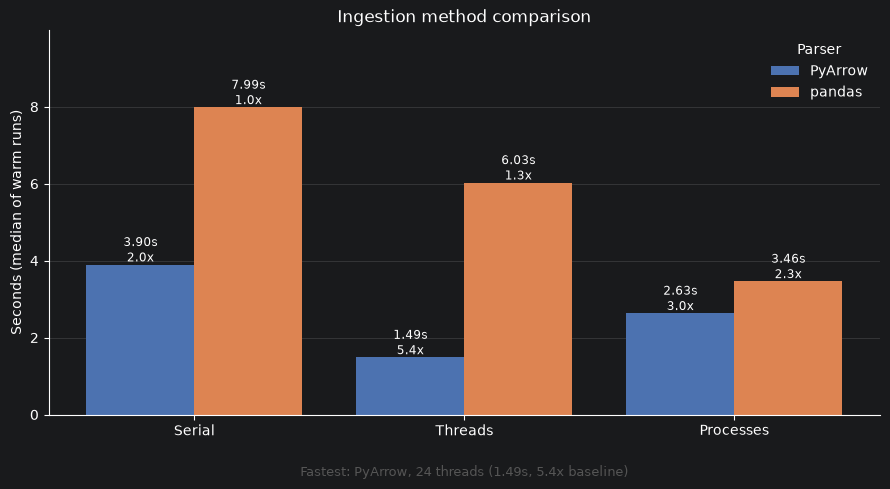

In [11]:
# Comparing the methods
import re
import matplotlib.pyplot as plt
import numpy as np

MODE_ORDER = ["serial", "threads", "processes"]

def plot_benchmark(results, title="Ingestion method comparison", figsize=(9, 5)):
    df = pd.Series(results, name="seconds").rename_axis("method").reset_index()
    df["parser"] = df.method.str.split(",").str[0].str.strip()
    df["mode"] = df.method.str.extract(f"({'|'.join(MODE_ORDER)})", flags=re.I)

    if df["mode"].isna().any():
        fig, ax = plt.subplots(figsize=figsize)
        order = df.sort_values("seconds", ascending=False)
        ax.barh(order.method, order.seconds, color="#4C72B0")
        ax.set_xlabel("Seconds (median of warm runs)")
        ax.set_title(title)
        for y, v in enumerate(order.seconds):
            ax.text(v, y, f" {v:.2f}s", va="center", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        return ax

    grid = (
        df.pivot(index="mode", columns="parser", values="seconds")
        .reindex(MODE_ORDER)
        .dropna(how="all")
    )

    parsers = list(grid.columns)
    x = np.arange(len(grid))
    width = 0.8 / len(parsers)
    palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    fig, ax = plt.subplots(figsize=figsize)
    baseline = df.seconds.max()

    for i, parser in enumerate(parsers):
        offset = (i - (len(parsers) - 1) / 2) * width
        vals = grid[parser].values
        bars = ax.bar(x + offset, vals, width, label=parser,
                      color=palette[i % len(palette)])
        for bar, v in zip(bars, vals):
            if np.isnan(v):
                continue
            ax.text(bar.get_x() + bar.get_width() / 2, v,
                    f"{v:.2f}s\n{baseline / v:.1f}x",
                    ha="center", va="bottom", fontsize=8.5, linespacing=1.3)

    ax.set_xticks(x)
    ax.set_xticklabels([m.capitalize() for m in grid.index])
    ax.set_ylabel("Seconds (median of warm runs)")
    ax.set_title(title)
    ax.set_ylim(0, baseline * 1.25)
    ax.legend(title="Parser", frameon=False)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    fastest = df.loc[df.seconds.idxmin()]
    ax.annotate(
        f"Fastest: {fastest.method} ({fastest.seconds:.2f}s, "
        f"{baseline / fastest.seconds:.1f}x baseline)",
        xy=(0.5, -0.16), xycoords="axes fraction",
        ha="center", fontsize=9, color="#555",
    )
    plt.tight_layout()
    return ax

plot_benchmark(results)
plt.show()

### Comparing the ingestion methods

| Parser | Serial | Threads (24) | Processes (24) | Best |
|---|---|---|---|---|
| pandas | 7.99s | 6.03s | **3.46s** | processes |
| PyArrow | 3.90s | **1.49s** | 2.63s | threads |

Each figure is the median of three warm runs. All six loaders return identical output: a dict of ticker to date-indexed DataFrame, same seven columns; so the comparison reflects the method rather than differing amounts of work.

**The two parsers want opposite concurrency models.** This is the main finding, and it is not visible unless both dimensions are varied. Measured against its own serial baseline:

- pandas gains **2.31×** from processes but only **1.33×** from threads
- PyArrow gains **2.62×** from threads but only **1.48×** from processes

The GIL explains both halves. pandas performs its tokenising and type inference in Python, holding the interpreter lock throughout; twenty-four threads spend most of their time queuing for it, and the modest 1.33× gain comes almost entirely from overlapping the file reads themselves, which do release the lock. Processes have no shared lock to contend for, so pandas scales properly there.

PyArrow inverts this. Its CSV reader is C++ and explicitly releases the GIL while parsing, so threads deliver genuine parallelism at almost no cost: no interpreter startup, no serialisation of results back to the parent. Moving the same work to processes pays those costs to buy parallelism that threads were already providing for free, which is why it gives up more than a second against the threaded result.

**The parser advantage varies with concurrency.** Holding execution fixed, PyArrow reads 2.05× faster serially (7.99s → 3.90s) and 4.05× faster with threads (6.03s → 1.49s), but only 1.32× faster with processes (3.46s → 2.63s). The narrowing under processes is the interesting part: a process pool pays a fixed cost before any file is read: twenty-four interpreters starting from scratch and importing their dependencies, then every resulting DataFrame pickled back to the parent. That cost is the same regardless of how fast the parsing itself is, so it dilutes any parser advantage.

**A note on run-to-run stability.** The process column is the least stable part of this benchmark. In earlier runs the ordering there reversed outright, with pandas at 2.76s beating PyArrow at 3.83s — the only configuration in which the slower parser finished first. The likely reason is that process startup dominates that cell, and the PyArrow workers carry the heavier import (both pandas and pyarrow, against pandas alone), so the two sit close enough together that scheduling noise can decide the order.

The qualitative conclusion has held across every run: pandas prefers processes, PyArrow prefers threads, and PyArrow with threads is fastest overall. The exact margins, particularly in the process column, should not be read to two decimal places. Three warm runs on one machine is enough to establish direction, not enough to rank configurations that finish within a second of each other.

**The best result is 1.49s, a 5.4× improvement over the naive baseline**, on a machine with 12 physical cores and 24 logical threads. That the return is well short of the core count reflects how much of the work stays serial regardless of worker count: listing the directory, opening each file, and merging the results into a single dict all happen in the parent process.

**This is not a Parquet comparison.** All six methods read the same CSV files; Arrow is used purely as a faster CSV parser. Converting the corpus to Parquet once and reading that instead would remove text parsing altogether and would likely produce a far larger gain than anything measured here. Worth testing separately.

**Caveats.** Timings are the median of three warm runs with a cold first pass discarded, so disk-cache effects and run ordering are controlled for. Three limitations remain:

- All warm runs read from the OS page cache, so these figures describe repeated reads of a resident dataset. A cold-storage or network-filesystem scenario would shift the balance towards I/O and compress the differences between parsers.
- Process-pool startup is included in the timings. This is deliberate (it is a real cost of the approach) but it means the process results reflect a one-shot load rather than a long-lived pool serving repeated work.
- Progress reporting runs inside the timed section. It is identical across all six methods, so it does not affect the comparison, but it inflates every absolute figure slightly.

The practical conclusion is that the parser and the concurrency model cannot be chosen independently: pandas with threads (6.03s) and PyArrow with processes (2.63s) are both worse than either library's own best configuration. Pairing each with the mechanism that suits it is what produces the 5.4× result.

### Aggregating across the corpus

With the data loaded, the first thing worth doing is a simple aggregate: the mean closing price of each ticker, and the extremes of that distribution. Each DataFrame is already indexed by date with numeric columns typed on read, so this is a single `.mean()` per ticker and a `min`/`max` over the resulting series.

Three quantities:

- the average closing price of every stock, keyed by symbol
- the symbol with the lowest average close
- the symbol with the highest average close

**A caveat on what this measures.** Mean closing price is a useful exercise in shaping the data, but it is close to meaningless as a comparison *between* companies. A share price is an arbitrary number: it reflects how many shares a company chose to issue, not how large or successful it is. A firm worth twice another can trade at a tenth of its price simply by having twenty times the shares outstanding. Splits move it discontinuously, and the tickers here cover different date ranges (a company that listed in 2019 is averaged over six years while one listed before 2007 is averaged over nineteen).

So the minimum and maximum below should be read as artefacts of price level and coverage, not as findings about the companies. Expect the extremes to be a low-priced small cap and something that never split. That is the correct result for the question as posed, and the reason the question is a warm-up rather than an analysis.

Comparing companies meaningfully requires normalising the price away, working in returns rather than levels, and using `adj_close`, which is corrected for splits and dividends. That is what the next section does. The aggregates here establish the mechanics and give a first look at the shape of the corpus.

In [12]:
# Average closing price by ticker
avg_close = pd.Series({ticker: df["close"].mean() for ticker, df in stock_prices.items()}, name="avg_close").sort_values()
coverage = pd.Series({ticker: len(df) for ticker, df in stock_prices.items()}, name="trading_days")

extremes = pd.concat([avg_close.head(3), avg_close.tail(3)]).to_frame()
extremes["trading_days"] = coverage
extremes["first_date"] = [stock_prices[t].index.min().date() for t in extremes.index]
extremes["rank"] = ["lowest"] * 3 + ["highest"] * 3
extremes["avg_close"] = extremes["avg_close"].map("${:,.2f}".format)

print(f"{len(avg_close):,} tickers | median ${avg_close.median():,.2f} | "
      f"lowest {avg_close.index[0]} (${avg_close.iloc[0]:,.2f}) | "
      f"highest {avg_close.index[-1]} (${avg_close.iloc[-1]:,.2f})")

extremes

1,363 tickers | median $25.22 | lowest SIR ($0.31) | highest TOPS ($20,386,430,342,101.91)


,avg_close,trading_days,first_date,rank
SIR,$0.31,3409,2012-03-07,lowest
SBNY,$1.05,346,2024-08-15,lowest
SGRP,$1.22,4780,2007-01-03,lowest
WHLR,"$23,380,063,896.81",3299,2012-11-19,highest
MRDN,"$66,200,649,901.11",4067,2009-10-30,highest
TOPS,"$20,386,430,342,101.91",4780,2007-01-03,highest


### The numbers are wrong, and the way they are wrong is informative

The minima look plausible; penny stocks, which the NASDAQ has no shortage of. The maxima do not. A $20 trillion share price is larger than the combined market capitalisation of every listed US company. No such price has ever existed, so the conclusion is not that these are expensive stocks; it is that something in the pipeline is producing values that cannot be real.

**First suspicion: my own ingest.** The PyArrow schema specified `float32`, which holds roughly seven significant digits and, past that, corrupts values silently rather than raising. That would fit; large numbers going quietly wrong is exactly the failure mode. Switching every column to `float64` changed nothing, which rules the loader out and moves the problem upstream. Reading the raw CSV directly confirmed it: the values are in the source data as downloaded.

**The actual cause is split adjustment.** `auto_adjust=False` suppresses *dividend* adjustment, but not splits; yfinance always back-applies the cumulative split factor to historical prices, so that the series is expressed in terms of today's share count. For a company that has repeatedly reverse-split, that factor compounds without limit.

The worst case is TOPS (Top Ships Inc.), a Greek shipping company with nineteen years of history and a long run of reverse splits:

| Year | Adjusted close        |
|---|-----------------------|
| 2007 | \$211,831,192,813,568 |
| 2013 | \$1,391,040,004,096   |
| 2016 | \$66,959,998,976      |
| 2019 | \$104,400             |
| 2022 | \$223.20              |
| 2025 | \$6.13                |

An 82.6 trillion-fold decline. The stock never traded above roughly $50 in reality; every pre-2020 figure is an artefact of restating old prices in units of a share that has since been consolidated many times over.

Note the direction of the bias. The three highest averages all have long histories - 3,299, 4,067 and 4,780 trading days - because a longer history means more splits to compound. The ranking is not measuring value; it is measuring which companies have restructured their share count most aggressively, which tends to mean the ones that have done worst.

**The minima have a different problem.** They are penny stocks, but one has only 346 trading days against another's 4,780. Averaging a fourteen-month window and a nineteen-year one produces numbers that are not comparable in either direction, regardless of splits.

**What this means for the exercise.** This is a concrete demonstration of the caveat stated at the top of the section: mean closing price is not a meaningful cross-company comparison. Here it is worse than uninformative; it is actively misleading, and confidently so. Any analysis built on raw price *levels* across this corpus inherits the distortion.

Two things follow, and the sections below take them in turn. First, the corpus can be screened for the pathology rather than treating TOPS as a one-off. Second, the underlying fix is to stop using levels at all: a split multiplies every price in a series by the same constant, and a constant cancels in a ratio, so returns are immune. TOPS' daily return series is entirely unremarkable(mean −0.31%, standard deviation 8.9%) despite its price series spanning fourteen orders of magnitude.

In [24]:
# Data quality: screening for split-adjustment artefacts
SPAN_THRESHOLD = 1_000

quality = pd.DataFrame({
    "first_close":  {t: df["close"].iloc[0]  for t, df in stock_prices.items()},
    "last_close":   {t: df["close"].iloc[-1] for t, df in stock_prices.items()},
    "max_close":    {t: df["close"].max()    for t, df in stock_prices.items()},
    "min_close":    {t: df["close"].min()    for t, df in stock_prices.items()},
    "trading_days": {t: len(df)              for t, df in stock_prices.items()},
})
quality["span"] = quality["max_close"] / quality["min_close"]

# If these are identical everywhere, auto_adjust=False gave us no separate dividend-adjusted series, and adj_close is a redundant column.
quality["adj_differs"] = {
    t: not np.allclose(df["close"], df["adj_close"], equal_nan=True)
    for t, df in stock_prices.items()
}

suspect = quality[quality["span"] > SPAN_THRESHOLD].sort_values("span", ascending=False)

print(f"{len(quality):,} tickers screened")
print(f"{len(suspect):,} exceed a {SPAN_THRESHOLD:,}x price span "
      f"({len(suspect) / len(quality):.1%})")
print(f"{quality['adj_differs'].sum():,} have adj_close differing from close "
      f"({quality['adj_differs'].mean():.1%})")

1,363 tickers screened
84 exceed a 1,000x price span (6.2%)
708 have adj_close differing from close (51.9%)


In [19]:
# Re-answering the original question on screened data
MIN_DAYS = 1_000   # roughly four years — enough for a mean to mean something

clean = quality[(quality["span"] <= SPAN_THRESHOLD) &
                (quality["trading_days"] >= MIN_DAYS)].index

avg_close_clean = pd.Series(
    {t: stock_prices[t]["close"].mean() for t in clean}, name="avg_close"
).sort_values()

print(f"Excluded {len(quality) - len(clean):,} of {len(quality):,} tickers "
      f"(>{SPAN_THRESHOLD:,}x span or <{MIN_DAYS:,} trading days); "
      f"{len(avg_close_clean):,} remain")
print(f"Lowest:  {avg_close_clean.index[0]} at ${avg_close_clean.iloc[0]:,.2f}")
print(f"Highest: {avg_close_clean.index[-1]} at ${avg_close_clean.iloc[-1]:,.2f}")
print(f"Median:  ${avg_close_clean.median():,.2f}")

extremes_clean = pd.concat([avg_close_clean.head(3), avg_close_clean.tail(3)]).to_frame()
extremes_clean["trading_days"] = quality["trading_days"]
extremes_clean["span"] = quality["span"].map("{:,.0f}x".format)
extremes_clean["rank"] = ["lowest"] * 3 + ["highest"] * 3
extremes_clean["avg_close"] = extremes_clean["avg_close"].map("${:,.2f}".format)

extremes_clean

Excluded 154 of 1,363 tickers (>1,000x span or <1,000 trading days); 1,209 remain
Lowest:  SIR at $0.31
Highest: CCUR at $14,418.53
Median:  $24.59


,avg_close,trading_days,span,rank
SIR,$0.31,3409,25x,lowest
SGRP,$1.22,4780,9x,lowest
NLST,$1.72,4780,124x,lowest
GALE,"$1,232.81",1174,10x,highest
CRIS,"$3,153.22",4780,556x,highest
CCUR,"$14,418.53",4780,30x,highest


In [37]:
# Cross-check the top suspects against their actual split history
# A result here compared the actual split history with the implied split history per our data. If it is similarly aligned, this confirms our hypothesis as to why the data has quality issues.
import yfinance as yf

INVESTIGATE = 3

for ticker in suspect.head(INVESTIGATE).index:
    splits = yf.Ticker(ticker).splits
    reverse = splits[splits < 1]
    implied = (1 / splits).prod() if len(splits) else 1
    print(f"{ticker}: {len(splits)} splits ({len(reverse)} reverse), "
          f"cumulative factor {implied:,.0f}x, "
          f"observed span {suspect.loc[ticker, 'span']:,.0f}x")

# Convert to returns: scale-invariant, so split adjustment cancels out
returns = pd.DataFrame(
    {t: df["adj_close"].pct_change() for t, df in stock_prices.items()}
).sort_index()

raw_max = pd.Series({t: d["close"].mean() for t, d in stock_prices.items()}).max()
print(f"\nHighest avg close (before data correction) — all tickers: ${raw_max:,.0f} | screened (post data correction): ${avg_close_clean.max():,.2f}")

BSPM: 2 splits (2 reverse), cumulative factor 21x, observed span infx
RNVA: 10 splits (10 reverse), cumulative factor 6,750,000,000,000,000,524,288x, observed span infx
ANTH: 2 splits (2 reverse), cumulative factor 64x, observed span infx

Highest avg close (before data correction) — all tickers: $20,386,430,342,102 | screened (post data correction): $14,418.53


### After screening: better, but not fixed

| | Ticker | Average close | Trading days | Span |
|---|--------|---------------|--------------|------|
| Lowest | SIR    | \$0.31        | 3,409        | 25×  |
| | SGRP   | \$1.22        | 4,780        | 9×   |
| | NLST   | \$1.72        | 4,780        | 124× |
| Highest | GALE   | \$1,232.81    | 1,174        | 10×  |
| | CRIS   | \$3,153.22    | 4,780        | 556× |
| | CCUR   | \$14,418.53   | 4,780        | 30×  |

The screen removed the trillion-dollar artefacts, and the minima now look entirely credible: SIR, SGRP and CETXP are small caps trading at genuine low-single-digit prices.

The maxima are still wrong. Curis (CRIS) and Concurrent Computer (CCUR) are small-cap companies that have never traded anywhere near four or five figures. The magnitudes have come down by ten orders of magnitude, but they have not become real.

**Why the screen missed them?** The filter tests `max_close / min_close`, which detects a series that *collapses* across the observation window. That catches TOPS, whose splits happened during the window and left recent prices in single digits against inflated early ones.

CCUR shows the blind spot: a span of only 30×, yet an average of $14,418. A low span with a high level means the series is inflated *uniformly* , consistent with the split adjustment arising largely from consolidations that occurred at or after the end of the window, so every in-window price is scaled by roughly the same factor and the ratio between them is preserved. The pathology is present; the symptom the filter looks for is not.

So the span test is a proxy for the problem, not a test of it. It catches the loudest cases and gives false confidence about the rest.

**What a real test would look like.** Two options, neither cheap:

1. Query `yf.Ticker(t).splits` for each ticker and divide out the cumulative factor directly. Correct, but it needs one network call per ticker and the reconstruction is lossy at extreme factors.
2. Cross-reference against an independent price source and flag any series whose level disagrees materially.

Both are worth doing if as-traded prices are genuinely required. Neither is worth doing here, because the analysis does not require them.

**The conclusion stands, more firmly than before.** Two rounds of filtering have not produced a trustworthy answer to "which stock has the highest average closing price", and the reason is not that the filters were badly chosen. The question itself has no reliable answer in this data, because share price level is an arbitrary quantity that the source has already transformed in ways that are not recoverable from the series alone.

Returns do not have this problem. A split multiplies every price in a series by the same constant, and a constant cancels in a ratio - so a series can be inflated by 30×, 556× or 82 trillion× and its return series is unaffected. That is the subject of the next section, and this exercise is the argument for it.